In [15]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from numpy.polynomial.polynomial import Polynomial
from scipy.optimize import curve_fit

In [16]:
# F_Data is a Matrix, each row is a time series
S_Data = np.load("S.npy")
t = np.arange(0,4097,1)
t_list = [ i for i in range(0,4097,1)]


In [17]:
def detrended_fluctuation_analysis(time_series, min_scale=4, max_scale=4096, num_scales=20, order=1):
    N = len(time_series)

    # Compute profile
    mean_x = np.mean(time_series)
    Y = np.cumsum(time_series - mean_x)

    # Define scales
    scales = np.logspace(np.log10(min_scale), np.log10(max_scale), num_scales, dtype=int)
    F = []

    # Loop over scales
    for s in scales:
        segments = N // s
        rms = []

        for i in range(segments):
            idx = slice(i * s, (i + 1) * s)
            segment = Y[idx]
            x = np.arange(len(segment))

            # Fit polynomial trend of the LOCAL TREND
            m,c = np.polyfit(x, segment, order)
            trend = (m * x) + c

            # Compute RMS OF LOCAL FLUCTUATIONS
            fluctuation = np.sqrt(np.mean((segment - trend) ** 2))
            rms.append(fluctuation)

        # Compute RMS MEAN
        F.append(np.sqrt(np.mean(np.array(rms)**2)))

    # Fit scaling exponent
    scales = np.array(scales)
    F = np.array(F)     # F is the RMS MEAN
    coeffs = np.polyfit(np.log(scales), np.log(F), 1)
    alpha = coeffs[0]
    
    return scales, F, coeffs, alpha

In [18]:
#Data Generation
idx = 0
for j in range(5):
    for i in range(20):
        scales, F, coeffs, alpha = detrended_fluctuation_analysis(S_Data[idx], min_scale=4, max_scale=4096, num_scales=20, order=1)
        np.save(f'scalesS{idx}.npy', scales)
        np.save(f'rmsmeanS{idx}.npy', F)
        np.save(f'coeffsS{idx}.npy', coeffs)
        np.save(f'alphaS{idx}.npy', alpha)
        idx += 1

C:\Users\rjnar\AppData\Local\Temp\ipykernel_12736\3492619574.py:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('viridis')


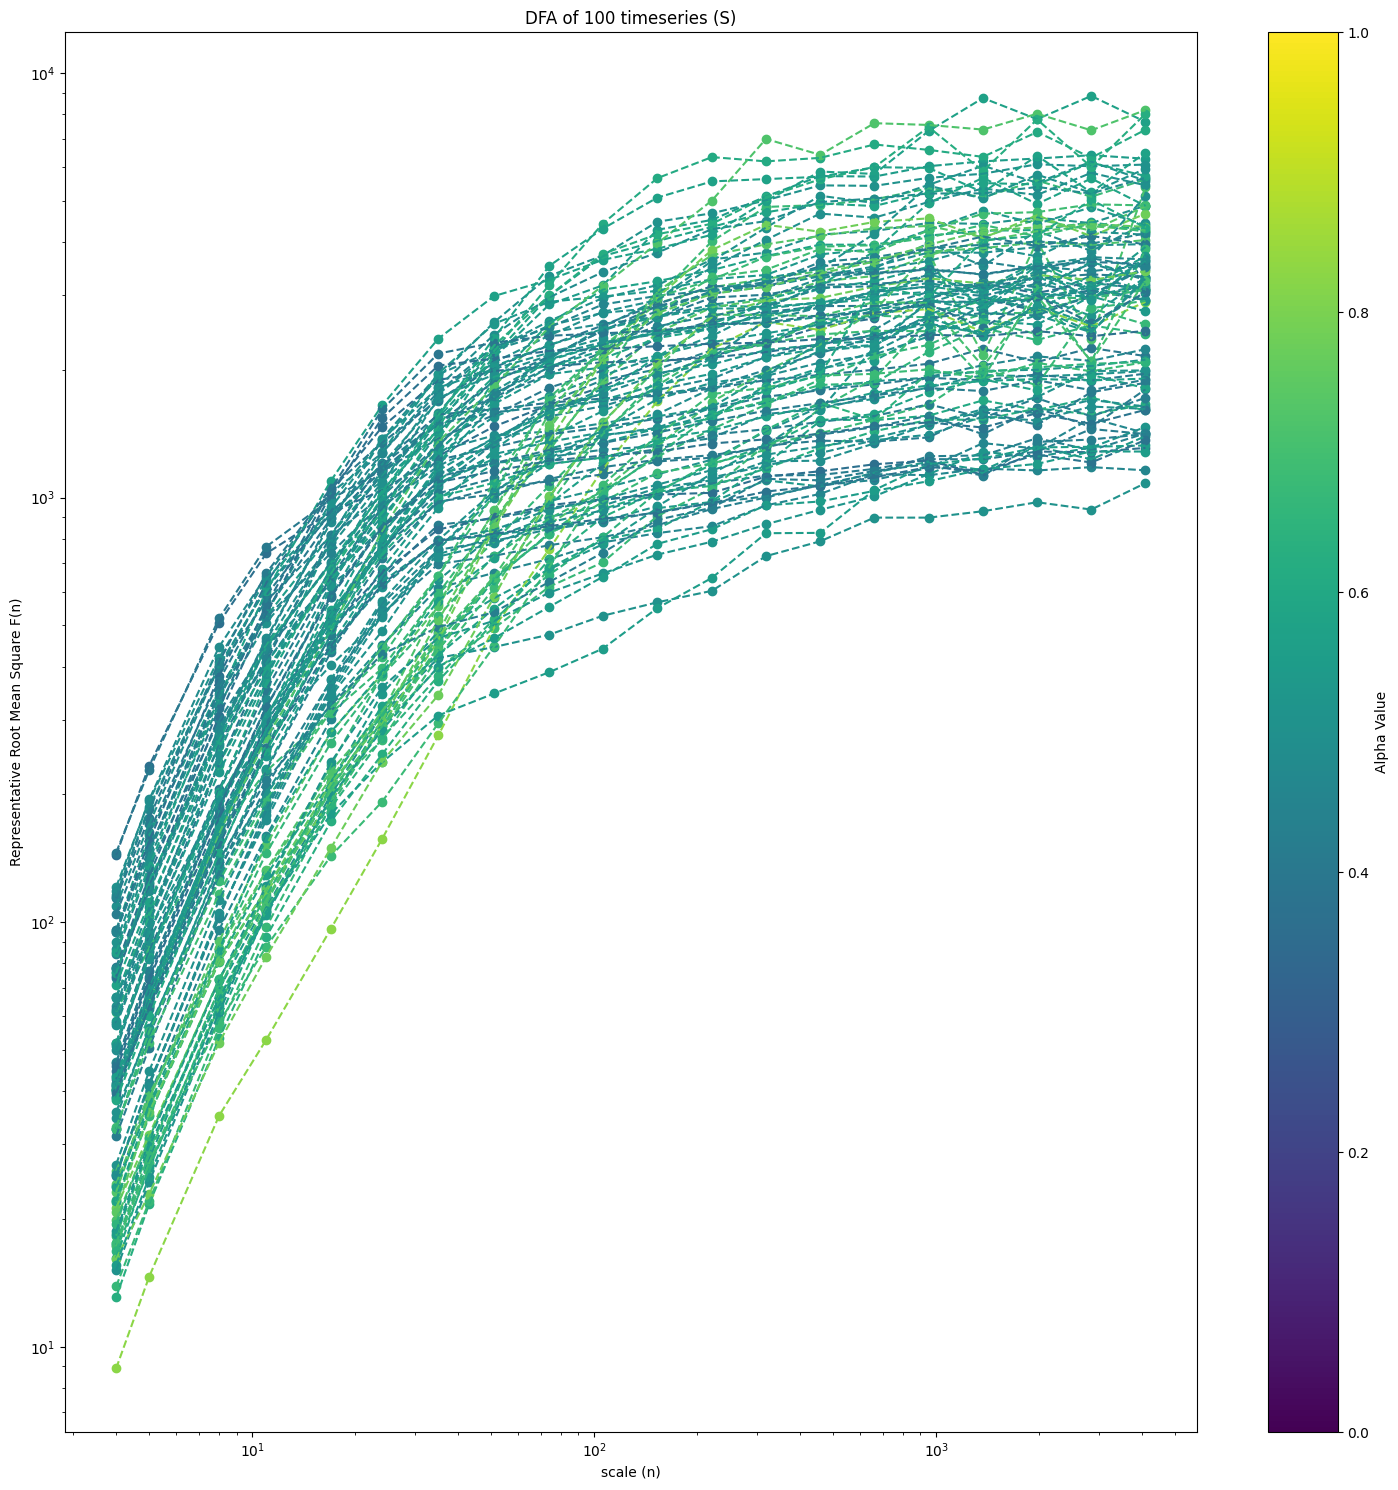

In [19]:
# Plotting
cmap = cm.get_cmap('viridis')
fig, axs = plt.subplots( figsize = (15,15))
idx = 0

for i in range(100):
    scales = np.load(f'scalesS{idx}.npy')
    F = np.load(f'rmsmeanS{idx}.npy')
    coeffs = np.load(f'coeffsS{idx}.npy')
    alpha = np.load(f'alphaS{idx}.npy')


    color = cmap(alpha)
    axs.scatter(scales, F, color=color, label='Fluctuation function')
    axs.plot(scales, F, '--' , color=color)
    idx += 1

axs.set_xscale('log')
axs.set_yscale('log')
axs.set_xlabel('scale (n)')
axs.set_ylabel("Representative Root Mean Square F(n)")
axs.set_title(f'DFA of 100 timeseries (S)')  # Fixed method
    

plt.tight_layout()

sm = cm.ScalarMappable(cmap=cmap, norm=mcolors.Normalize(vmin=0, vmax=1))
cbar = plt.colorbar(sm, ax=axs)
cbar.set_label('Alpha Value')

plt.savefig("DFA for S.png", dpi=72)
